In [ ]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load DataSet
df = pd.read_csv("/content/Walmart DataSet.csv")

In [ ]:
# Shape of data
print("Shape:", df.shape)

Shape: (6435, 8)


In [ ]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
# Statistical summary
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


1. Sales change a lot: Weekly sales go up and down a lot across stores and weeks.
2. Holidays matter: About 7% of weeks are holidays, which probably changes how much people buy.
3. Outside factors vary: Things like temperature, gas prices, and unemployment also change a lot, and these likely affect sales.
**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [ ]:
print(df.isnull().sum())

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [ ]:
# Extract features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

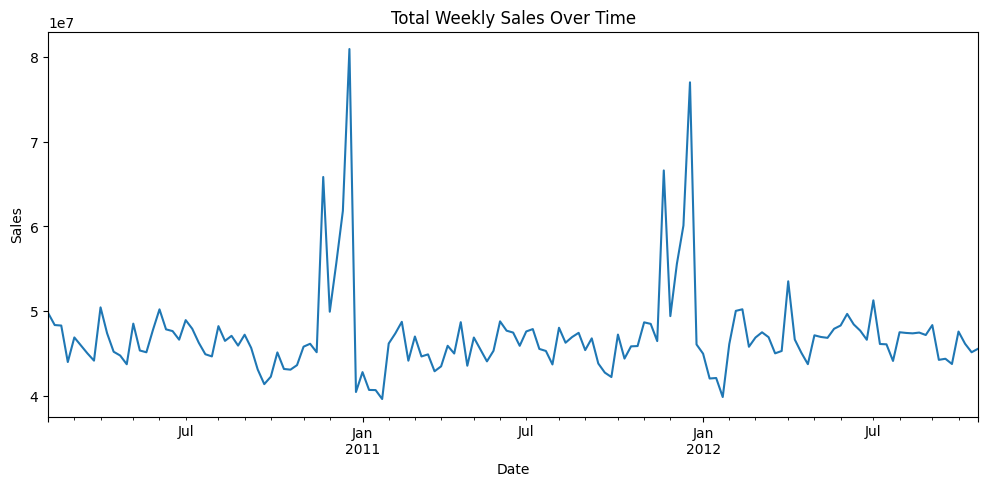

In [ ]:
# Weekly Sales Trend
plt.figure(figsize= (12,5))
df.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

**Store-wise Performance**

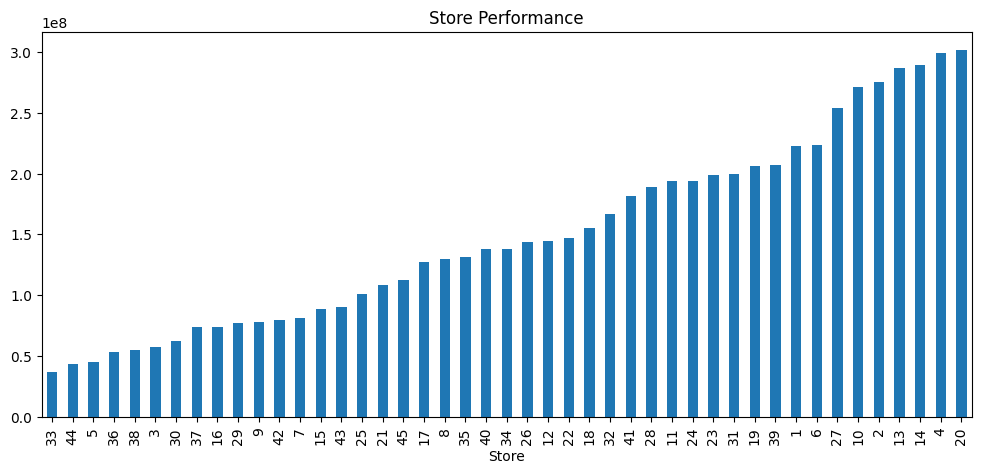

In [ ]:
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values()

plt.figure(figsize=(12,5))
store_sales.plot(kind='bar')
plt.title("Store Performance")
plt.show()

**Seasonal Trend (Month-wise)**

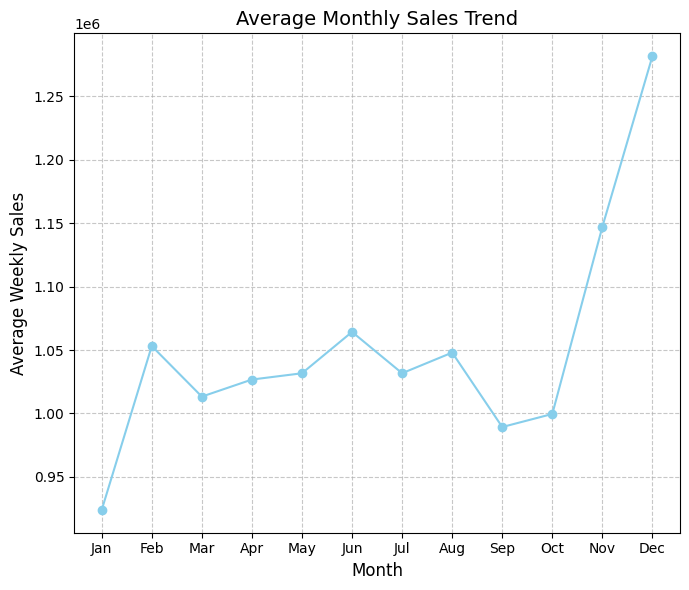

In [ ]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()

plt.figure(figsize=(7, 6))
monthly_sales.plot(marker='o', linestyle='-', color='skyblue')
plt.title("Average Monthly Sales Trend", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Weekly Sales", fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Holiday Impact**

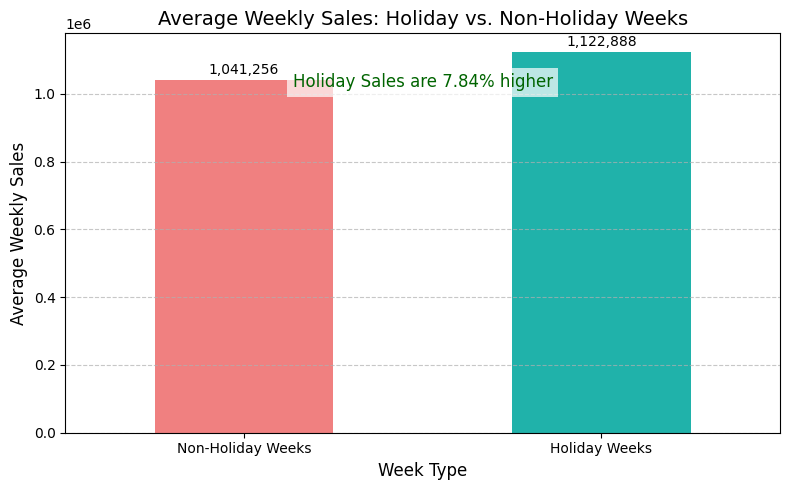

In [ ]:
non_holiday_sales = df[df['Holiday_Flag'] == 0]['Weekly_Sales'].mean()
holiday_sales = df[df['Holiday_Flag'] == 1]['Weekly_Sales'].mean()
percentage_change = ((holiday_sales - non_holiday_sales) / non_holiday_sales) * 100

plt.figure(figsize=(8, 5))
df.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(kind='bar', color=['lightcoral', 'lightseagreen'])
plt.title("Average Weekly Sales: Holiday vs. Non-Holiday Weeks", fontsize=14)
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Average Weekly Sales", fontsize=12)
plt.xticks([0, 1], ['Non-Holiday Weeks', 'Holiday Weeks'], rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for index, value in df.groupby('Holiday_Flag')['Weekly_Sales'].mean().items():
    plt.text(index, value + 10000, f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

# Add percentage change annotation
plt.text(0.5, plt.ylim()[1] * 0.9, f'Holiday Sales are {percentage_change:,.2f}% higher',
         ha='center', va='top', fontsize=12, color='darkgreen', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

**📉 Correlation Analysis**

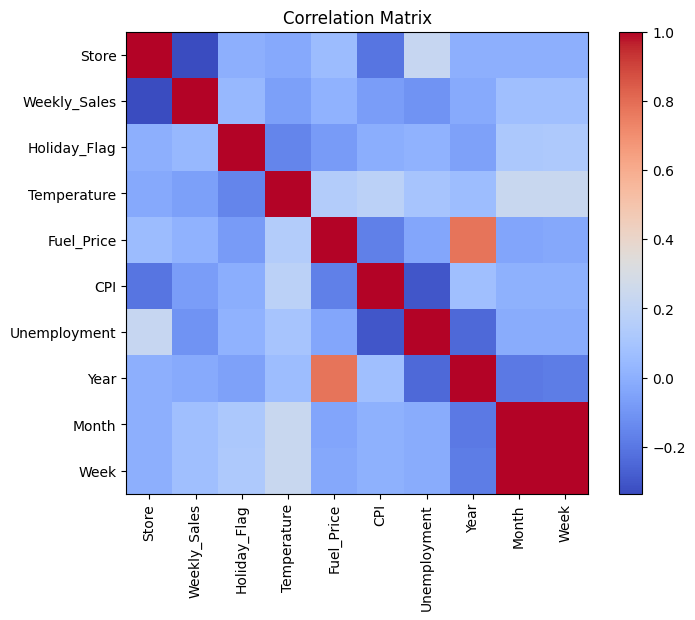

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()



*   List itWeekly Sales and Store have a negative relationship: This means larger store numbers tend to have lower weekly sales.
* Weekly Sales and Holiday Flag have a weak positive relationship: Sales are slightly higher during holiday weeks.
* Weekly Sales and Temperature have a weak negative relationship: Higher temperatures slightly reduce sales.
* Weekly Sales and CPI (Consumer Price Index) have a weak negative relationship: As consumer prices go up, sales tend to slightly go down.
* Weekly Sales and Unemployment have a weak negative relationship: Higher unemployment rates slightly lead to lower sales.

In general, while some factors show minor connections, none of the variables like temperature, fuel price, CPI, or unemployment have a very strong direct link to weekly sales.





# **📦 Outlier Analysis**

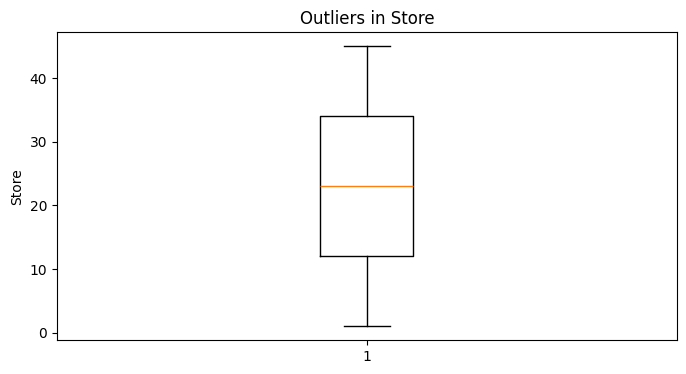

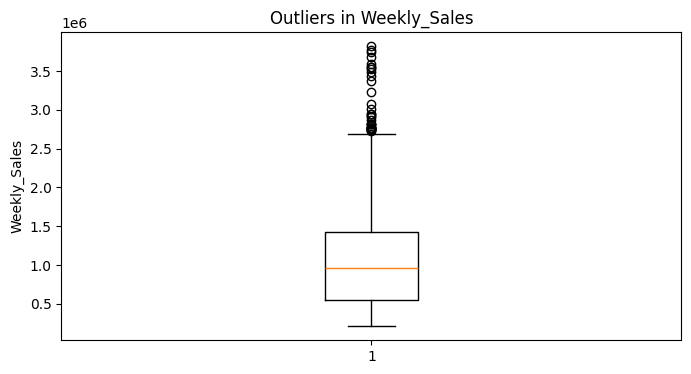

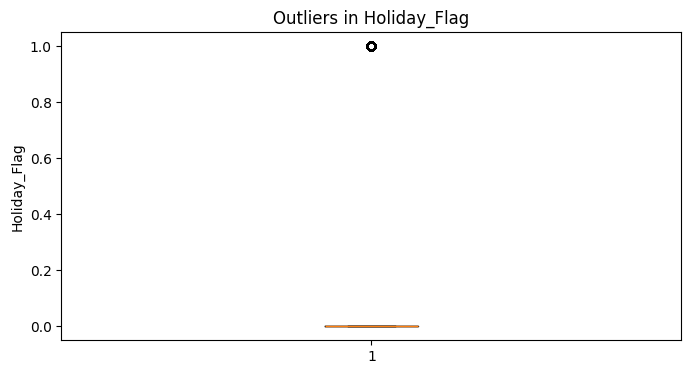

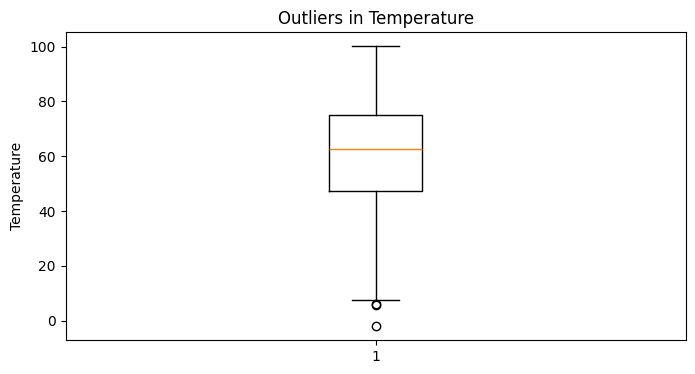

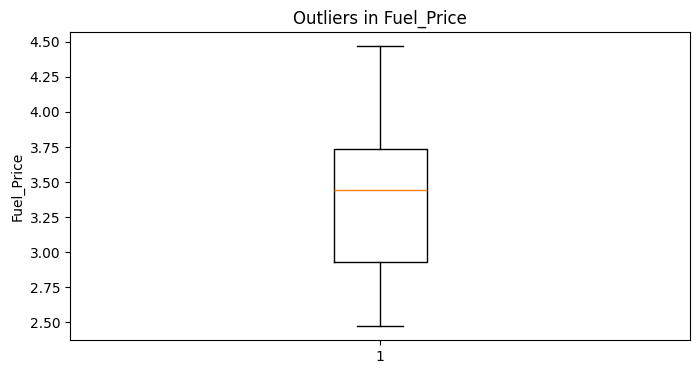

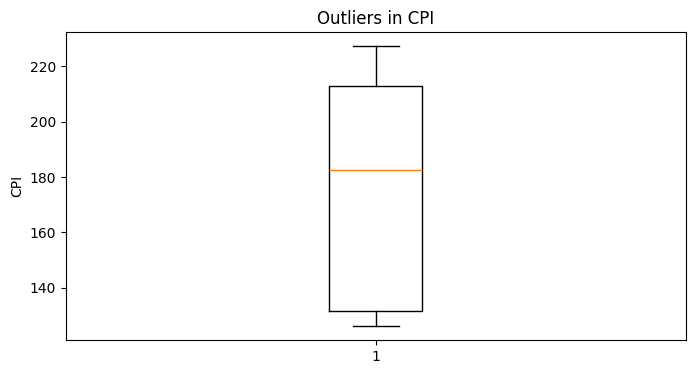

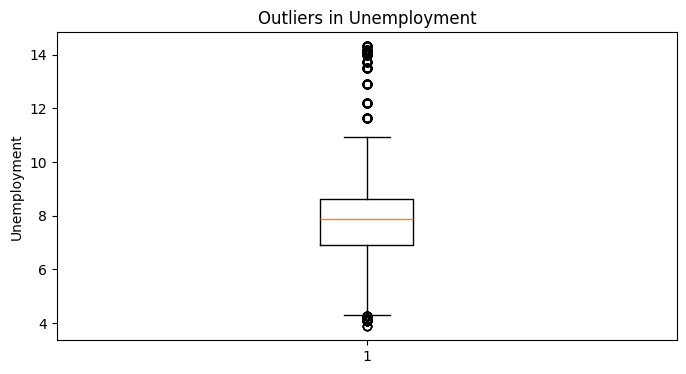

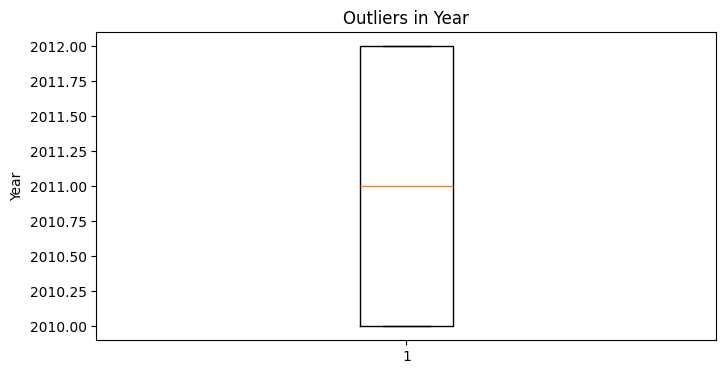

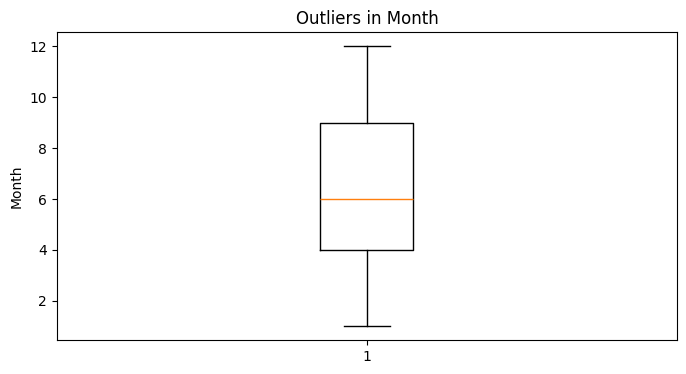

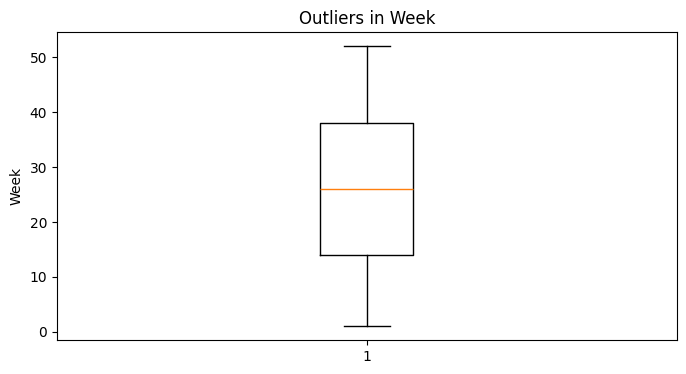

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Outliers in {col}")
    plt.ylabel(col)
    plt.show()

In [ ]:
df_clean = df.copy()
columns_to_check = ['Weekly_Sales', 'Temperature', 'Unemployment']
rows_before_cleaning = df_clean.shape[0]

for col in columns_to_check:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

rows_after_cleaning = df_clean.shape[0]
rows_removed = rows_before_cleaning - rows_after_cleaning
percentage_removed = (rows_removed / rows_before_cleaning) * 100

print(f"Number of rows before outlier removal: {rows_before_cleaning}")
print(f"Number of rows after outlier removal: {rows_after_cleaning}")
print(f"Total rows removed: {rows_removed}")
print(f"Percentage of rows removed: {percentage_removed:.2f}%")


Number of rows before outlier removal: 6435
Number of rows after outlier removal: 6435
Total rows removed: 0
Percentage of rows removed: 0.00%


**Unemployment Impact**

In [ ]:
print(df_clean[['Weekly_Sales','Unemployment']].corr())

              Weekly_Sales  Unemployment
Weekly_Sales      1.000000     -0.106176
Unemployment     -0.106176      1.000000


**The correlation coefficient between 'Weekly_Sales' and 'Unemployment' after outlier removal is approximately -0.106. This indicates a weak negative correlation between the two variables. In simpler terms:

   * As unemployment slightly increases, weekly sales tend to slightly decrease.
   * As unemployment slightly decreases, weekly sales tend to slightly increase.
   
It's important to note that this is a very weak relationship, meaning unemployment doesn't have a strong linear impact on weekly sales in this cleaned dataset.**

**Temperature Impact**



In [ ]:
print(df_clean[['Weekly_Sales','Temperature']].corr())

              Weekly_Sales  Temperature
Weekly_Sales       1.00000     -0.06381
Temperature       -0.06381      1.00000


The correlation coefficient between 'Weekly_Sales' and 'Temperature' after outlier removal is approximately -0.064. This indicates a very weak negative correlation between the two variables. In simpler terms:

   * As temperature slightly increases, weekly sales tend to slightly decrease.
   * As temperature slightly decreases, weekly sales tend to slightly increase.
   
Similar to unemployment, this is a very weak relationship, meaning temperature does not have a strong linear impact on weekly sales in this cleaned dataset.

**CPI Impact**

In [ ]:
print(df_clean[['Weekly_Sales','CPI']].corr())

              Weekly_Sales       CPI
Weekly_Sales      1.000000 -0.072634
CPI              -0.072634  1.000000


The correlation coefficient between 'Weekly_Sales' and 'CPI' (Consumer Price Index) after outlier removal is approximately -0.0726. This indicates a very weak negative correlation between the two variables. In simpler terms:

   * As the Consumer Price Index (CPI) slightly increases, weekly sales tend to slightly decrease.
   * As the Consumer Price Index (CPI) slightly decreases, weekly sales tend to slightly increase.
   
This is a very weak relationship, suggesting that CPI does not have a strong linear impact on weekly sales in this cleaned dataset.



Top & Worst Stores

In [ ]:
store_perf = df_clean.groupby('Store')['Weekly_Sales'].sum()

top_store = store_perf.idxmax()
worst_store = store_perf.idxmin()

print("Top Store:", top_store)
print("Worst Store:", worst_store)

print("Difference:", store_perf.max() - store_perf.min())

Top Store: 20
Worst Store: 33
Difference: 264237570.49999997


**Store Ranking Table**

In [ ]:
store_perf.sort_values(ascending=False).head(10)

,Weekly_Sales
Store,
20,3.013978e+08
4,2.995440e+08
14,2.889999e+08
13,2.865177e+08
2,2.753824e+08
10,2.716177e+08
27,2.538559e+08
6,2.237561e+08
1,2.224028e+08


#if the weekly sales are affected by the unemployment rate, if yes - which stores are suffering the most?

In [ ]:
# Store-wise correlation
store_corr = df_clean.groupby('Store').apply(
    lambda x: x['Weekly_Sales'].corr(x['Unemployment'])
)

# Convert to DataFrame
store_corr = store_corr.reset_index()
store_corr.columns = ['Store', 'Correlation']

# Sort (most affected first)
store_corr = store_corr.sort_values(by='Correlation')

store_corr.head(10)

,Store,Correlation
37,38,-0.785290
43,44,-0.780076
38,39,-0.384681
41,42,-0.356355
40,41,-0.350630
3,4,-0.337015
16,17,-0.263600
2,3,-0.230413
36,37,-0.221287
4,5,-0.207043


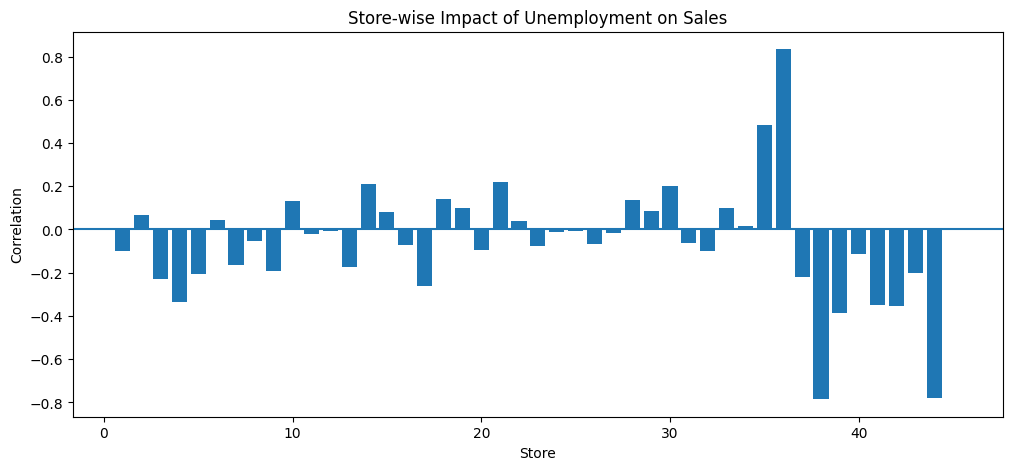

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.bar(store_corr['Store'], store_corr['Correlation'])
plt.axhline(0)  # zero line
plt.title("Store-wise Impact of Unemployment on Sales")
plt.xlabel("Store")
plt.ylabel("Correlation")
plt.show()

In [ ]:
# Filter strongly affected stores
strong_impact = store_corr[store_corr['Correlation'] < -0.3]

strong_impact

,Store,Correlation
37,38,-0.785290
43,44,-0.780076
38,39,-0.384681
41,42,-0.356355
40,41,-0.350630
3,4,-0.337015


**If the weekly sales show a seasonal trend, when and what could be the reason?**

Monthly Seasonality (Clear Pattern)

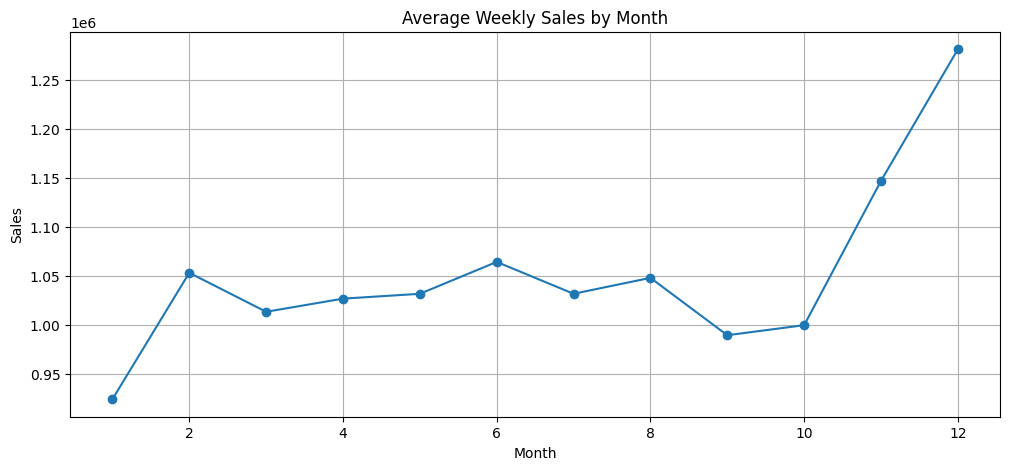

,mean,sum
Month,,
1,9.238846e+05,3.325984e+08
2,1.053200e+06,5.687279e+08
3,1.013309e+06,5.927859e+08
4,1.026762e+06,6.468598e+08
5,1.031714e+06,5.571256e+08
6,1.064325e+06,6.226299e+08
7,1.031748e+06,6.500010e+08
8,1.048017e+06,6.130902e+08
9,9.893353e+05,5.787612e+08


In [ ]:
monthly_sales = df_clean.groupby('Month')['Weekly_Sales'].agg(['mean','sum'])

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales['mean'], marker='o')
plt.title("Average Weekly Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid()
plt.show()

monthly_sales

In [ ]:
selected_months_sales = monthly_sales.loc[2:10, 'sum']
total_sales_2_to_10 = selected_months_sales.sum()
average_sales_2_to_10 = total_sales_2_to_10 / 9

print(f"Total Weekly Sales for Months 2 to 10: {total_sales_2_to_10:,.2f}")
print(f"Average Weekly Sales per month (from 2 to 10): {average_sales_2_to_10:,.2f}")

Total Weekly Sales for Months 2 to 10: 5,414,766,188.41
Average Weekly Sales per month (from 2 to 10): 601,640,687.60


**Year-wise Seasonal Pattern (Trend + Repeatability)**

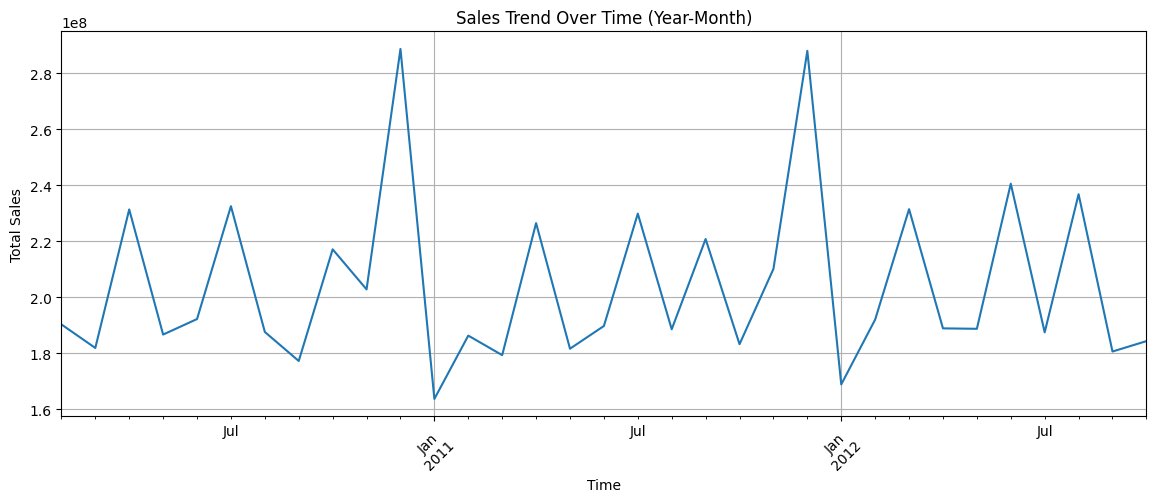

In [ ]:
df_clean['YearMonth'] = df_clean['Date'].dt.to_period('M')

trend = df_clean.groupby('YearMonth')['Weekly_Sales'].sum()

plt.figure(figsize=(14,5))
trend.plot()
plt.title("Sales Trend Over Time (Year-Month)")
plt.xlabel("Time")
plt.ylabel("Total Sales")
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.grid()
plt.show()

**Holiday Impact (Root Cause Analysis)**

In [ ]:
holiday_effect = df_clean.groupby('Holiday_Flag')['Weekly_Sales'].agg(['mean','sum'])

holiday_effect

,mean,sum
Holiday_Flag,,
0,1.041256e+06,6.231919e+09
1,1.122888e+06,5.052996e+08


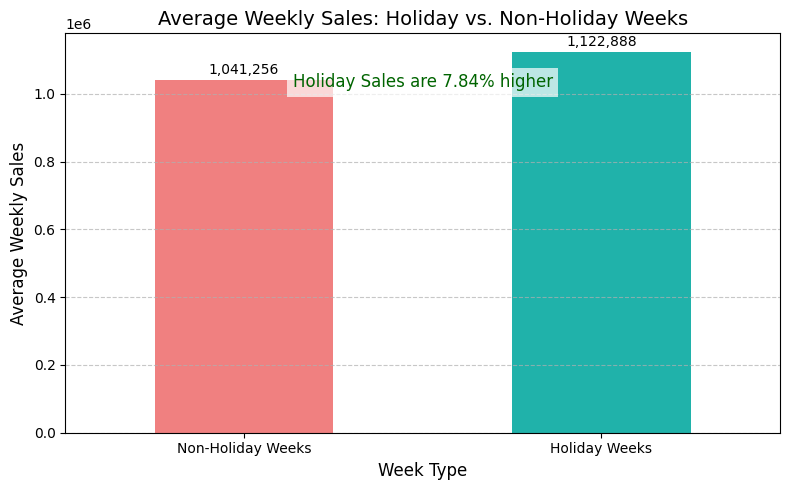

In [ ]:
non_holiday_sales = df[df['Holiday_Flag'] == 0]['Weekly_Sales'].mean()
holiday_sales = df[df['Holiday_Flag'] == 1]['Weekly_Sales'].mean()
percentage_change = ((holiday_sales - non_holiday_sales) / non_holiday_sales) * 100

plt.figure(figsize=(8, 5))
df.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(kind='bar', color=['lightcoral', 'lightseagreen'])
plt.title("Average Weekly Sales: Holiday vs. Non-Holiday Weeks", fontsize=14)
plt.xlabel("Week Type", fontsize=12)
plt.ylabel("Average Weekly Sales", fontsize=12)
plt.xticks([0, 1], ['Non-Holiday Weeks', 'Holiday Weeks'], rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
for index, value in df.groupby('Holiday_Flag')['Weekly_Sales'].mean().items():
    plt.text(index, value + 10000, f'{value:,.0f}', ha='center', va='bottom', fontsize=10)

# Add percentage change annotation
plt.text(0.5, plt.ylim()[1] * 0.9, f'Holiday Sales are {percentage_change:,.2f}% higher',
         ha='center', va='top', fontsize=12, color='darkgreen', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()
plt.show()

**Week-wise Deep Seasonality**

In [ ]:
import plotly.express as px

In [ ]:
# Ensure 'Week' is in integer format for better plotting
df_clean['Week'] = df_clean['Date'].dt.isocalendar().week.astype(int)

weekly_pattern = df_clean.groupby('Week')['Weekly_Sales'].mean().reset_index()

fig = px.line(
    weekly_pattern,
    x='Week',
    y='Weekly_Sales',
    title='Weekly Sales Pattern Across Year (Interactive)',
    labels={'Weekly_Sales': 'Average Weekly Sales'},
    markers=True
)

fig.update_layout(hovermode='x unified') # Unified hover mode for better interaction
fig.show()

**Store-wise Seasonality**

In [ ]:
store_month = df_clean.groupby(['Store','Month'])['Weekly_Sales'].mean().unstack()

store_month.head()

Month,1,2,3,4,5,6,7,8,9,10,11,12
Store,,,,,,,,,,,,
1,1.400468e+06,1.625442e+06,1.567744e+06,1.544510e+06,1.542111e+06,1.561510e+06,1.479006e+06,1.547581e+06,1.487055e+06,1.497581e+06,1.668815e+06,1790954.789
2,1.733240e+06,2.031104e+06,1.901645e+06,1.880910e+06,1.891239e+06,1.948405e+06,1.835354e+06,1.895008e+06,1.778456e+06,1.829181e+06,2.108592e+06,2396695.096
3,3.694999e+05,4.335837e+05,4.074922e+05,3.952136e+05,3.928796e+05,4.008956e+05,3.769606e+05,3.861959e+05,3.784725e+05,3.874933e+05,4.463619e+05,484469.719
4,1.918984e+06,2.183575e+06,2.041075e+06,2.006260e+06,2.032642e+06,2.063358e+06,1.998500e+06,2.085018e+06,2.008490e+06,2.054847e+06,2.329136e+06,2561152.081
5,2.860521e+05,3.205875e+05,3.129764e+05,3.234867e+05,3.187843e+05,3.206952e+05,2.997468e+05,3.074842e+05,3.055804e+05,3.020777e+05,3.617861e+05,376067.083


 **The single most important thing these graphs tell us is that seasonal sales patterns vary significantly from store to store. While there are general trends, each store has its own unique monthly performance profile,which means a one-size-fits-all sales strategy won't be effective.**

# ***conclusion***

 Q) Do weekly sales show a seasonal trend?

-> Yes, weekly sales clearly show a seasonal pattern.

Q) When does this seasonality happen?
->
Sales are highest in November and December
Sales increase during holiday weeks
Sales go down in January and February (after holidays)

Q) Why does this happen?
1.  Holiday Effect (Main Reason)
People spend more during holidays
Festivals and celebrations increase shopping
Sales go up because of offers and discounts
2.  Promotions and Discounts
Stores give special offers and sales
Clearance sales attract more customers
This creates short-term spikes in sales
3.  Weather Changes
People buy different things in different seasons
Example:
Winter → warm clothes
Summer → cooling products
4.  Repeating Pattern
Same sales pattern happens every year
So, it is not random, it is predictable


Sales follow a clear pattern based on holidays and customer behavior.
This means businesses can plan better for future demand.



Stores should:

Increase stock before high-demand months (Nov–Dec)
Reduce stock in low-demand months (Jan–Feb)


# **Q} Does temperature affect the weekly sales in any manner?**

In [ ]:
# Correlation between Temperature and Sales
corr_temp = df_clean[['Weekly_Sales', 'Temperature']].corr()

print("Correlation between Temperature and Weekly Sales:\n")
print(corr_temp)

Correlation between Temperature and Weekly Sales:

              Weekly_Sales  Temperature
Weekly_Sales       1.00000     -0.06381
Temperature       -0.06381      1.00000


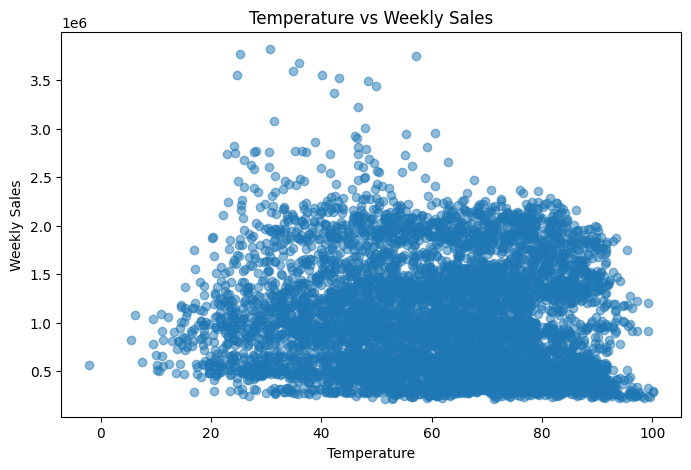

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df_clean['Temperature'], df_clean['Weekly_Sales'], alpha=0.5)
plt.title("Temperature vs Weekly Sales")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

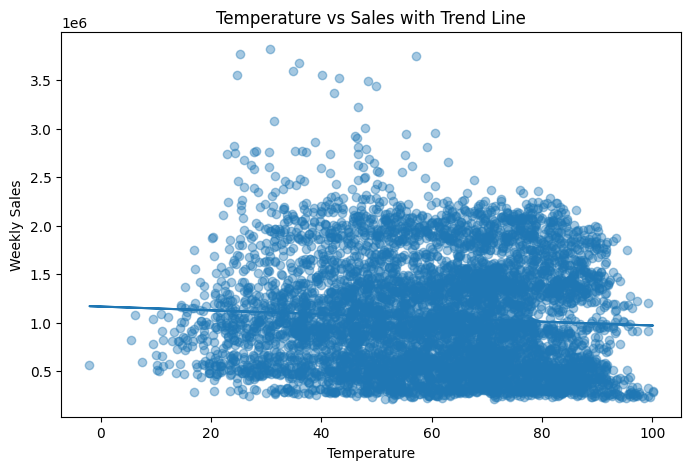

In [ ]:
x = df_clean['Temperature']
y = df_clean['Weekly_Sales']

# Fit line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4)
plt.plot(x, p(x))  # trend line
plt.title("Temperature vs Sales with Trend Line")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.show()

In [ ]:
store_temp = df_clean.groupby('Store').apply(
    lambda x: x['Weekly_Sales'].corr(x['Temperature'])
)

store_temp.sort_values().head(10)

,0
Store,
10,-0.432569
12,-0.379416
3,-0.377524
28,-0.376506
30,-0.330816
8,-0.312324
37,-0.300493
2,-0.297673
34,-0.278523


Temperature ka impact weak hai
Scatter plot me points mostly random spread hai
Trend line almost flat hogi

✔ Means:

Temperature affects type of products, not overall sales much

# **How is the Consumer Price index affecting the weekly sales of various stores?**

In [ ]:
# Overall CPI vs Sales relationship
corr_cpi = df_clean[['Weekly_Sales', 'CPI']].corr()

print("Overall Correlation (CPI vs Weekly Sales):\n")
print(corr_cpi)

Overall Correlation (CPI vs Weekly Sales):

              Weekly_Sales       CPI
Weekly_Sales      1.000000 -0.072634
CPI              -0.072634  1.000000


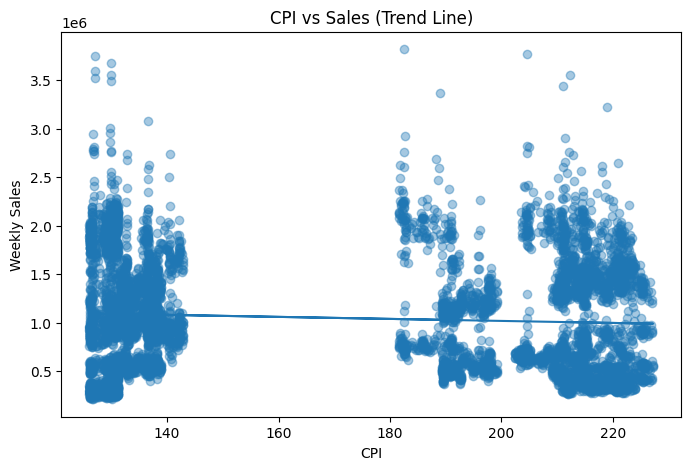

In [ ]:
import numpy as np

x = df_clean['CPI']
y = df_clean['Weekly_Sales']

# Fit linear trend
z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.4)
plt.plot(x, p(x))
plt.title("CPI vs Sales (Trend Line)")
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")
plt.show()

In [ ]:
# Store-wise CPI impact
store_cpi = df_clean.groupby('Store').apply(
    lambda x: x['Weekly_Sales'].corr(x['CPI'])
)

# Convert to DataFrame
store_cpi = store_cpi.reset_index()
store_cpi.columns = ['Store', 'CPI_Impact']

# Sort (most affected first)
store_cpi = store_cpi.sort_values(by='CPI_Impact')

print(store_cpi.head(10))

    Store  CPI_Impact
35     36   -0.915095
34     35   -0.424107
13     14   -0.419755
29     30   -0.298188
42     43   -0.285686
26     27   -0.213082
17     18   -0.193541
14     15   -0.174467
20     21   -0.163649
18     19   -0.155341


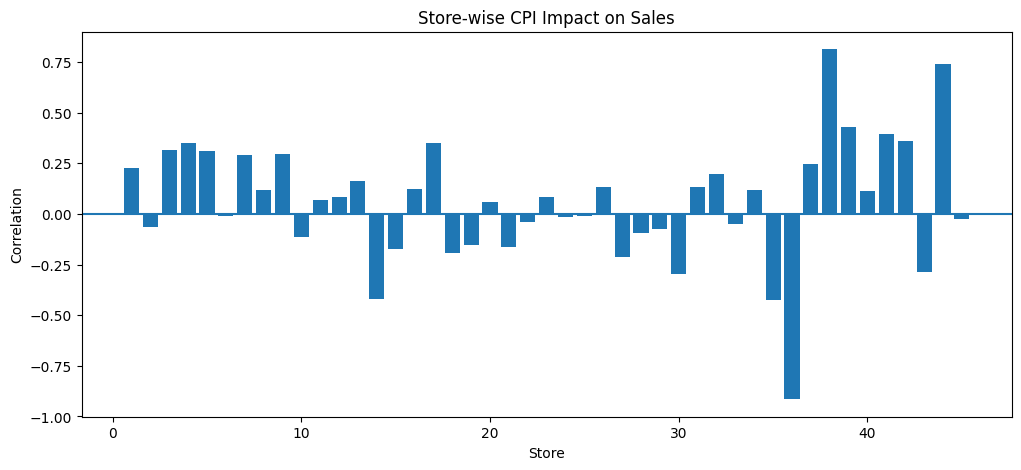

In [ ]:
plt.figure(figsize=(12,5))
plt.bar(store_cpi['Store'], store_cpi['CPI_Impact'])
plt.axhline(0)
plt.title("Store-wise CPI Impact on Sales")
plt.xlabel("Store")
plt.ylabel("Correlation")
plt.show()

In [ ]:
# Strong negative impact
low_cpi_impact = store_cpi[store_cpi['CPI_Impact'] < -0.3]

print("Stores negatively affected by CPI:\n")
print(low_cpi_impact)

Stores negatively affected by CPI:

    Store  CPI_Impact
35     36   -0.915095
34     35   -0.424107
13     14   -0.419755


In [ ]:
import seaborn as sns

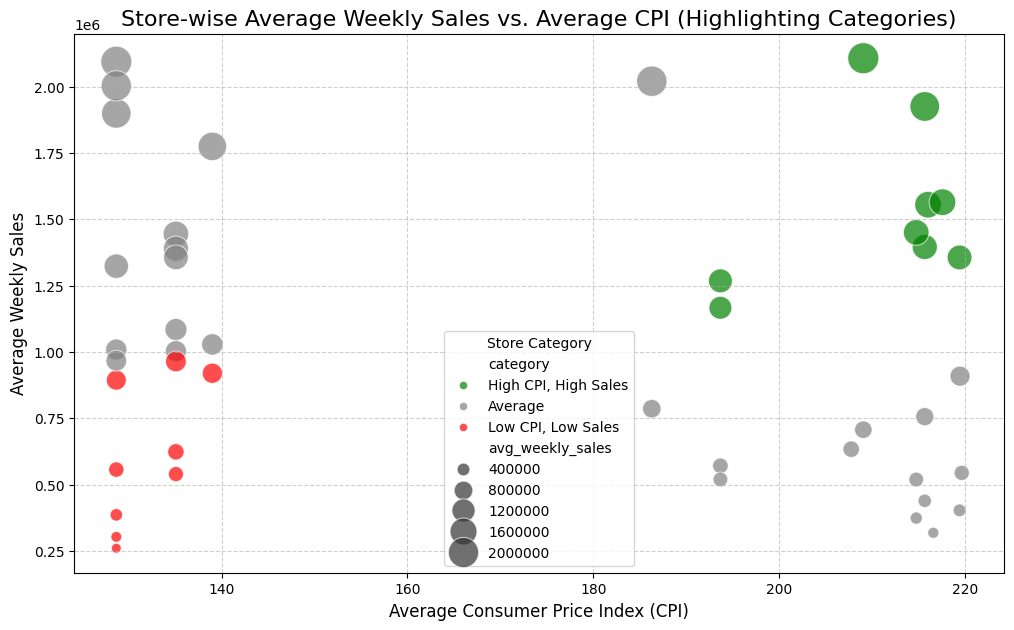

In [ ]:
store_avg_data = df_clean.groupby('Store').agg(
    avg_weekly_sales=('Weekly_Sales', 'mean'),
    avg_cpi=('CPI', 'mean')
).reset_index()

# Identify stores based on conditions (example: above median for both, or below median for both)
median_sales = store_avg_data['avg_weekly_sales'].median()
median_cpi = store_avg_data['avg_cpi'].median()

store_avg_data['category'] = 'Average'
store_avg_data.loc[
    (store_avg_data['avg_cpi'] > median_cpi) &
    (store_avg_data['avg_weekly_sales'] > median_sales),
    'category'
] = 'High CPI, High Sales'
store_avg_data.loc[
    (store_avg_data['avg_cpi'] < median_cpi) &
    (store_avg_data['avg_weekly_sales'] < median_sales),
    'category'
] = 'Low CPI, Low Sales'

# Create the scatter plot with highlighted categories
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=store_avg_data,
    x='avg_cpi',
    y='avg_weekly_sales',
    hue='category', # Color points based on the new category
    size='avg_weekly_sales', # Size points by sales to emphasize high sales
    sizes=(50, 500), # Range of sizes
    alpha=0.7,
    palette={'High CPI, High Sales': 'green', 'Low CPI, Low Sales': 'red', 'Average': 'gray'}
)

# Add labels and title
plt.title('Store-wise Average Weekly Sales vs. Average CPI (Highlighting Categories)', fontsize=16)
plt.xlabel('Average Consumer Price Index (CPI)', fontsize=12)
plt.ylabel('Average Weekly Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Store Category')
plt.show()

In [ ]:
# Step 1: Store-level average
store_summary = df_clean.groupby('Store').agg({
    'Weekly_Sales': 'mean',
    'CPI': 'mean'
}).reset_index()

# Step 2: Thresholds (median based)
cpi_threshold = store_summary['CPI'].median()
sales_threshold = store_summary['Weekly_Sales'].median()

# Step 3: Filter stores
result_stores = store_summary[
    (store_summary['CPI'] > cpi_threshold) &   # High CPI
    (store_summary['Weekly_Sales'] > sales_threshold)  # High Sales
]['Store']

# Step 4: Print only Store IDs
print("Store IDs (High CPI but High Sales):\n")
print(result_stores.tolist())

Store IDs (High CPI but High Sales):

[1, 2, 6, 11, 20, 31, 32, 39, 41]


CPI has a moderate to weak impact on weekly sales
In some stores, higher CPI leads to lower sales (reduced purchasing power)
In other stores, impact is minimal

✔ Means:

CPI effect is not uniform across stores
Local economic conditions matter

**Top performing stores according to the historical data.**

In [ ]:
store_performance = df_clean.groupby('Store')['Weekly_Sales'].sum()

# Sort descending (highest first)
top_stores = store_performance.sort_values(ascending=False)

# Top 5 stores
top_5 = top_stores.head(5)

print("Top Performing Stores:\n")
print(top_5)

Top Performing Stores:

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64


In [ ]:
print("Top Store IDs:\n")
print(top_5.index.tolist())

Top Store IDs:

[20, 4, 14, 13, 2]


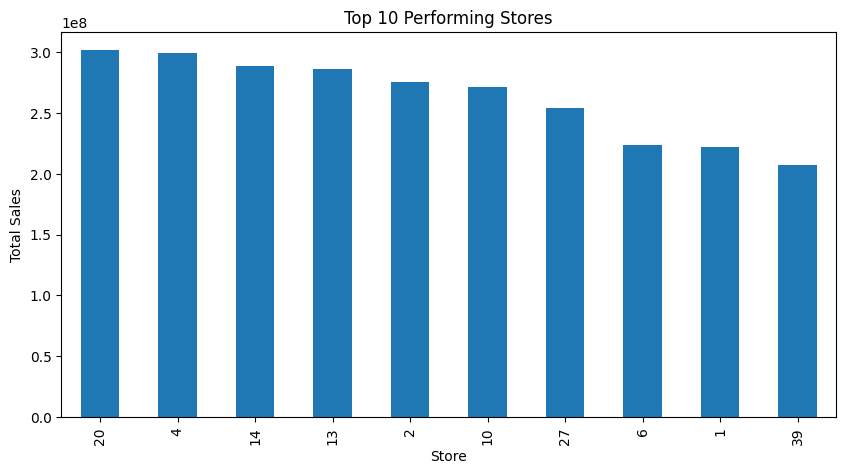

In [ ]:
import matplotlib.pyplot as plt

top_10 = top_stores.head(10)

plt.figure(figsize=(10,5))
top_10.plot(kind='bar')
plt.title("Top 10 Performing Stores")
plt.xlabel("Store")
plt.ylabel("Total Sales")
plt.show()

as per the weekly_sale the top best performing store is 20,4,14,13,and 2

In [ ]:
# Total sales per store
store_sales = df_clean.groupby('Store')['Weekly_Sales'].sum()

# Best and worst store
best_store = store_sales.idxmax()
worst_store = store_sales.idxmin()

# Values
max_sales = store_sales.max()
min_sales = store_sales.min()

# Difference
difference = max_sales - min_sales

# Output
print("Best Store:", best_store)
print("Worst Store:", worst_store)
print("Difference in Sales:", difference)

Best Store: 20
Worst Store: 33
Difference in Sales: 264237570.49999997


In [ ]:
# Step 1: Total sales per store
store_sales = df_clean.groupby('Store')['Weekly_Sales'].sum().reset_index()

# Step 2: Create 5 segments (quintiles)
store_sales['Segment'] = pd.qcut(store_sales['Weekly_Sales'], 5, labels=[
    'Very Low',
    'Low',
    'Medium',
    'High',
    'Very High'
])

# Step 3: Sort for clarity
store_sales = store_sales.sort_values(by='Weekly_Sales', ascending=False)

# Step 4: Output
print(store_sales)

    Store  Weekly_Sales    Segment
19     20  3.013978e+08  Very High
3       4  2.995440e+08  Very High
13     14  2.889999e+08  Very High
12     13  2.865177e+08  Very High
1       2  2.753824e+08  Very High
9      10  2.716177e+08  Very High
26     27  2.538559e+08  Very High
5       6  2.237561e+08  Very High
0       1  2.224028e+08  Very High
38     39  2.074455e+08       High
18     19  2.066349e+08       High
30     31  1.996139e+08       High
22     23  1.987506e+08       High
23     24  1.940160e+08       High
10     11  1.939628e+08       High
27     28  1.892637e+08       High
40     41  1.813419e+08       High
31     32  1.668192e+08       High
17     18  1.551147e+08     Medium
21     22  1.470756e+08     Medium
11     12  1.442872e+08     Medium
25     26  1.434164e+08     Medium
33     34  1.382498e+08     Medium
39     40  1.378703e+08     Medium
34     35  1.315207e+08     Medium
7       8  1.299512e+08     Medium
16     17  1.277821e+08     Medium
44     45  1.123953e

In [ ]:
# Grouped output
segmented_stores = store_sales.groupby('Segment')['Store'].apply(list)

print(segmented_stores)

Segment
Very Low       [16, 37, 30, 3, 38, 36, 5, 44, 33]
Low            [45, 21, 25, 43, 15, 7, 42, 9, 29]
Medium        [18, 22, 12, 26, 34, 40, 35, 8, 17]
High         [39, 19, 31, 23, 24, 11, 28, 41, 32]
Very High        [20, 4, 14, 13, 2, 10, 27, 6, 1]
Name: Store, dtype: object


**SARIMA** MODEL

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
# Convert date
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Aggregate total weekly sales (all stores)
ts = df_clean.groupby('Date')['Weekly_Sales'].sum()

# Sort index
ts = ts.sort_index()

ts.head()

,Weekly_Sales
Date,
2010-02-05,49750740.50
2010-02-12,48336677.63
2010-02-19,48276993.78
2010-02-26,43968571.13
2010-03-05,46871470.30


In [ ]:
model = SARIMAX(ts,
                order=(1,1,1),
                seasonal_order=(1,1,1,12))

model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.



                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2233.569
Date:                            Thu, 02 Apr 2026   AIC                           4477.137
Time:                                    06:01:09   BIC                           4491.475
Sample:                                02-05-2010   HQIC                          4482.963
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1800      0.319      0.565      0.572      -0.444       0.805
ma.L1         -0.5343      0.286   

In [ ]:
forecast = model_fit.forecast(steps=12)

print("Next 12 Weeks Forecast:\n")
print(forecast)

Next 12 Weeks Forecast:

2012-11-02    4.287564e+07
2012-11-09    4.496524e+07
2012-11-16    4.575773e+07
2012-11-23    4.745774e+07
2012-11-30    4.459657e+07
2012-12-07    4.339778e+07
2012-12-14    4.418745e+07
2012-12-21    4.491168e+07
2012-12-28    4.379498e+07
2013-01-04    4.439133e+07
2013-01-11    4.477258e+07
2013-01-18    4.747699e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


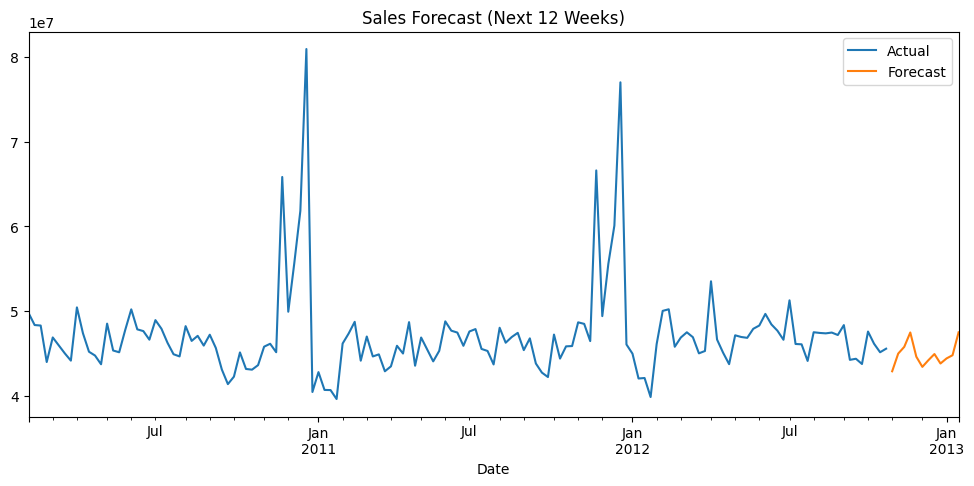

In [ ]:
plt.figure(figsize=(12,5))

# Original data
ts.plot(label='Actual')

# Forecast
forecast.plot(label='Forecast')

plt.title("Sales Forecast (Next 12 Weeks)")
plt.legend()
plt.show()

In [ ]:
# Example for one store
store_1 = df_clean[df_clean['Store'] == 1]
ts_store = store_1.groupby('Date')['Weekly_Sales'].sum()

model = SARIMAX(ts_store, order=(1,1,1), seasonal_order=(1,1,1,12))
model_fit = model.fit()

forecast_store = model_fit.forecast(steps=12)
forecast_store

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.



,predicted_mean
2012-11-02,1.421157e+06
2012-11-09,1.511237e+06
2012-11-16,1.498984e+06
2012-11-23,1.571846e+06
2012-11-30,1.510895e+06
2012-12-07,1.472766e+06
2012-12-14,1.497334e+06
2012-12-21,1.504977e+06
2012-12-28,1.498639e+06
2013-01-04,1.497632e+06



 Forecast for Store 5



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.



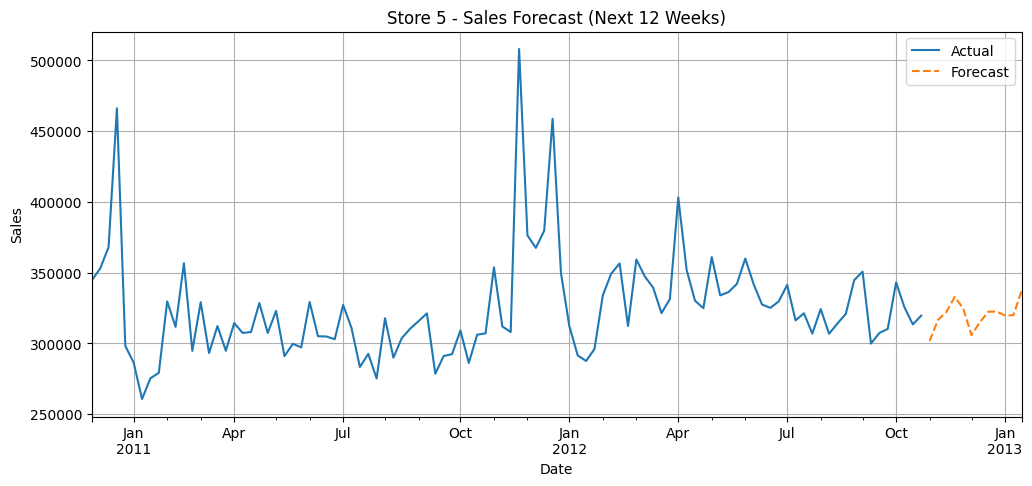


 Forecast for Store 33



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.



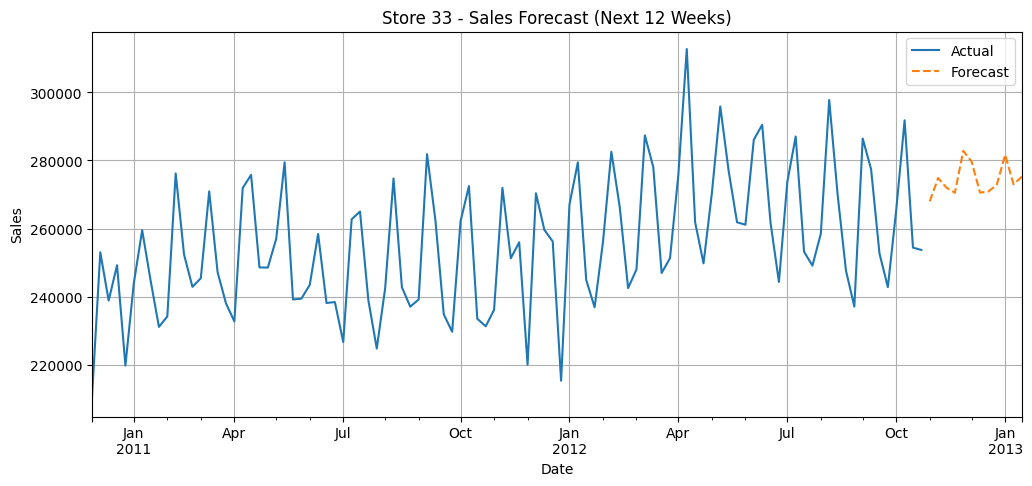


 Forecast for Store 45



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.



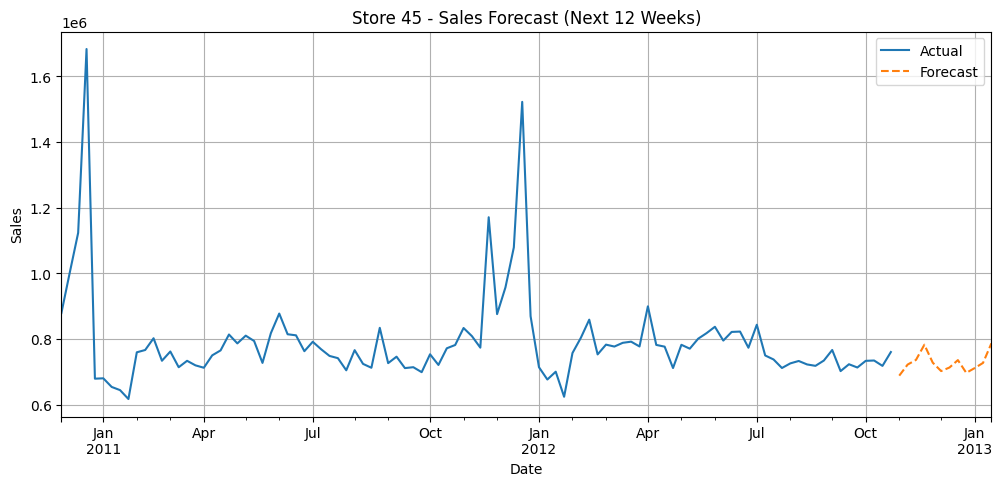


 Forecast for Store 22



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.



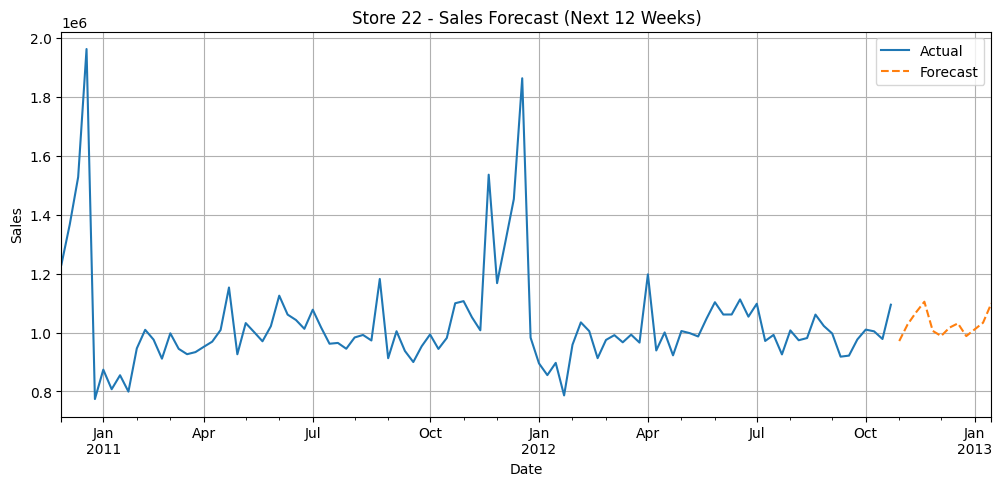


 Forecast for Store 20



/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency W-FRI will be used.



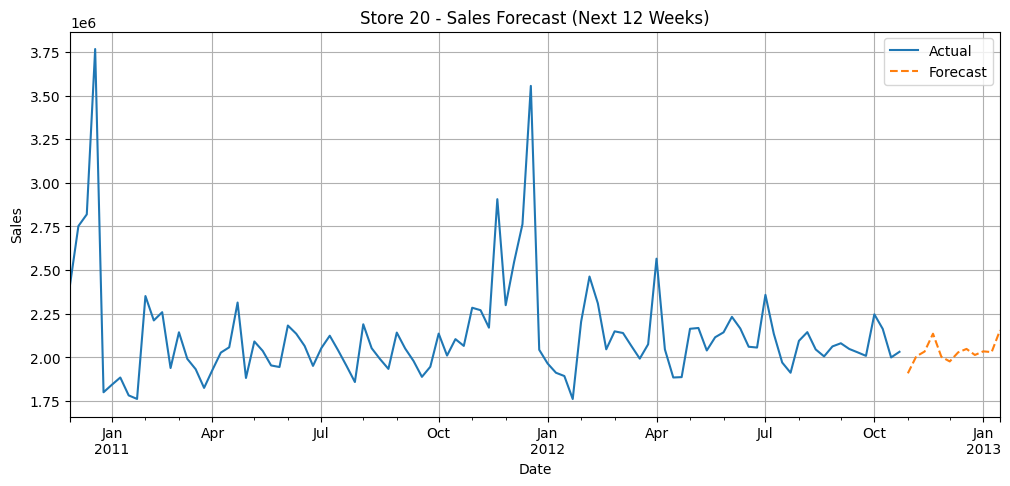

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# Stores list
stores = [5, 33, 45, 22, 20]

# Ensure date format
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

for store in stores:
    print(f"\n Forecast for Store {store}\n")

    # Filter data for store
    store_data = df_clean[df_clean['Store'] == store]

    # Time series
    ts = store_data.groupby('Date')['Weekly_Sales'].sum().sort_index()

    # Model
    model = SARIMAX(ts,
                    order=(1,1,1),
                    seasonal_order=(1,1,1,12))

    model_fit = model.fit(disp=False)

    # Forecast
    forecast = model_fit.forecast(steps=12)

    # Future dates
    future_dates = pd.date_range(start=ts.index[-1], periods=13, freq='W')[1:]
    forecast.index = future_dates

    # 🔥 Plot
    plt.figure(figsize=(12,5))

    ts.tail(100).plot(label='Actual')
    forecast.plot(label='Forecast', linestyle='--')

    plt.title(f"Store {store} - Sales Forecast (Next 12 Weeks)")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid()

    plt.show()